# In Silico Perturbation Results Analysis
## Cop1 WT → KO Gene Deletion Perturbation

This notebook analyzes the output of Geneformer in silico perturbation.
We examine which genes, when deleted, most shift cell embeddings from **Cop1_WT** toward **Cop1_KO**.

**Key columns:**
- `Shift_to_goal_end`: Cosine similarity shift toward goal state (Cop1_KO)
- `Goal_end_vs_random_pval`: P-value vs random perturbation
- `Goal_end_FDR`: FDR-corrected p-value
- `Sig`: Binary significance flag

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Style settings
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (12, 6)

# Load the ISP results
CSV_PATH = "/app/output/ispstats_results/output_in-silico_SEdelete_ORCop1KO_STCop1_WT_ENCop1_KO.csv"
df = pd.read_csv(CSV_PATH, index_col=0)

print(f"Total genes analyzed: {len(df)}")
print(f"Significant genes (Sig=1): {df['Sig'].sum()}")
print(f"\nColumn names: {list(df.columns)}")
df.head(10)

## 1. Summary Statistics

In [ ]:
print("=" * 60)
print("Summary Statistics for Shift_to_goal_end")
print("=" * 60)
print(df['Shift_to_goal_end'].describe())

print(f"\n--- Significance Summary ---")
print(f"Genes with FDR < 0.05: {(df['Goal_end_FDR'] < 0.05).sum()}")
print(f"Genes with FDR < 0.10: {(df['Goal_end_FDR'] < 0.10).sum()}")
print(f"Genes with FDR < 0.25: {(df['Goal_end_FDR'] < 0.25).sum()}")
print(f"Genes with p-value < 0.05: {(df['Goal_end_vs_random_pval'] < 0.05).sum()}")

print(f"\n--- Top 10 Positive Shifters (→ Cop1_KO) ---")
top_pos = df.nlargest(10, 'Shift_to_goal_end')[['Gene_name', 'Ensembl_ID', 'Shift_to_goal_end', 'Goal_end_FDR', 'Sig']]
print(top_pos.to_string(index=False))

print(f"\n--- Top 10 Negative Shifters (→ away from Cop1_KO) ---")
top_neg = df.nsmallest(10, 'Shift_to_goal_end')[['Gene_name', 'Ensembl_ID', 'Shift_to_goal_end', 'Goal_end_FDR', 'Sig']]
print(top_neg.to_string(index=False))

## 2. Distribution of Cosine Similarity Shifts

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of all shifts
ax = axes[0]
ax.hist(df['Shift_to_goal_end'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Zero shift')
ax.set_xlabel('Shift to Goal End (Cop1_KO)')
ax.set_ylabel('Number of Genes')
ax.set_title('Distribution of Cosine Similarity Shifts')
ax.legend()

# Histogram of p-values
ax = axes[1]
ax.hist(df['Goal_end_vs_random_pval'], bins=50, color='coral', edgecolor='white', alpha=0.8)
ax.axvline(x=0.05, color='red', linestyle='--', linewidth=1.5, label='p=0.05')
ax.set_xlabel('P-value (vs random)')
ax.set_ylabel('Number of Genes')
ax.set_title('Distribution of P-values')
ax.legend()

plt.tight_layout()
plt.savefig('/app/output/ispstats_results/shift_distribution.png', bbox_inches='tight')
plt.show()

## 3. Volcano Plot (Shift vs Significance)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# Calculate -log10(FDR) for volcano plot
df['neg_log10_fdr'] = -np.log10(df['Goal_end_FDR'].clip(lower=1e-300))
df['neg_log10_pval'] = -np.log10(df['Goal_end_vs_random_pval'].clip(lower=1e-300))

# Color by significance
colors = np.where(df['Goal_end_FDR'] < 0.05, 'red',
         np.where(df['Goal_end_vs_random_pval'] < 0.05, 'orange', 'grey'))

ax.scatter(df['Shift_to_goal_end'], df['neg_log10_pval'],
           c=colors, alpha=0.5, s=20, edgecolors='none')

# Label top genes
n_label = 15
top_genes = pd.concat([
    df.nlargest(n_label, 'Shift_to_goal_end'),
    df.nsmallest(n_label, 'Shift_to_goal_end')
]).drop_duplicates()

for _, row in top_genes.iterrows():
    ax.annotate(row['Gene_name'],
                (row['Shift_to_goal_end'], row['neg_log10_pval']),
                fontsize=7, alpha=0.8,
                textcoords="offset points", xytext=(5, 3))

ax.axhline(y=-np.log10(0.05), color='blue', linestyle='--', alpha=0.5, label='p=0.05')
ax.axvline(x=0, color='grey', linestyle='--', alpha=0.5)

ax.set_xlabel('Shift to Goal End (Cop1_KO)', fontsize=13)
ax.set_ylabel('-log10(p-value)', fontsize=13)
ax.set_title('Volcano Plot: Gene Deletion Effects on Cop1_WT → Cop1_KO Shift', fontsize=14)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='FDR < 0.05'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8, label='p < 0.05'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=8, label='Not significant'),
]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('/app/output/ispstats_results/volcano_plot.png', bbox_inches='tight')
plt.show()

## 4. Top Genes Bar Plot

In [ ]:
n_top = 25

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top positive shifters
top_pos = df.nlargest(n_top, 'Shift_to_goal_end')
ax = axes[0]
colors_pos = ['red' if s == 1 else 'steelblue' for s in top_pos['Sig']]
ax.barh(range(n_top), top_pos['Shift_to_goal_end'].values, color=colors_pos, edgecolor='white')
ax.set_yticks(range(n_top))
ax.set_yticklabels(top_pos['Gene_name'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Shift to Goal End')
ax.set_title(f'Top {n_top} Genes Shifting TOWARD Cop1_KO\n(deletion promotes KO phenotype)', fontsize=11)

# Top negative shifters
top_neg = df.nsmallest(n_top, 'Shift_to_goal_end')
ax = axes[1]
colors_neg = ['red' if s == 1 else 'coral' for s in top_neg['Sig']]
ax.barh(range(n_top), top_neg['Shift_to_goal_end'].values, color=colors_neg, edgecolor='white')
ax.set_yticks(range(n_top))
ax.set_yticklabels(top_neg['Gene_name'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Shift to Goal End')
ax.set_title(f'Top {n_top} Genes Shifting AWAY from Cop1_KO\n(deletion opposes KO phenotype)', fontsize=11)

plt.suptitle('Red bars = Statistically Significant (FDR-corrected)', fontsize=10, y=0.02, color='red')
plt.tight_layout()
plt.savefig('/app/output/ispstats_results/top_genes_barplot.png', bbox_inches='tight')
plt.show()

## 5. Ranked Gene Waterfall Plot

In [ ]:
df_sorted = df.sort_values('Shift_to_goal_end', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))

colors = ['steelblue' if v >= 0 else 'coral' for v in df_sorted['Shift_to_goal_end']]
ax.bar(range(len(df_sorted)), df_sorted['Shift_to_goal_end'], color=colors, width=1.0, edgecolor='none')

ax.set_xlabel('Gene Rank', fontsize=13)
ax.set_ylabel('Shift to Goal End', fontsize=13)
ax.set_title('Waterfall Plot: All Genes Ranked by Shift (Cop1_WT → Cop1_KO)', fontsize=14)
ax.axhline(y=0, color='black', linewidth=0.5)

# Annotate extremes
top1 = df_sorted.iloc[0]
bottom1 = df_sorted.iloc[-1]
ax.annotate(top1['Gene_name'], (0, top1['Shift_to_goal_end']),
            fontsize=9, fontweight='bold', xytext=(30, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'))
ax.annotate(bottom1['Gene_name'], (len(df_sorted)-1, bottom1['Shift_to_goal_end']),
            fontsize=9, fontweight='bold', xytext=(-80, -20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.savefig('/app/output/ispstats_results/waterfall_plot.png', bbox_inches='tight')
plt.show()

## 6. Export Filtered Results

In [ ]:
import os

output_dir = "/app/output/ispstats_results"

# Top 100 positive and negative shifters
top100_pos = df.nlargest(100, 'Shift_to_goal_end')[['Gene_name', 'Ensembl_ID', 'Shift_to_goal_end', 'Goal_end_vs_random_pval', 'Goal_end_FDR', 'Sig']]
top100_neg = df.nsmallest(100, 'Shift_to_goal_end')[['Gene_name', 'Ensembl_ID', 'Shift_to_goal_end', 'Goal_end_vs_random_pval', 'Goal_end_FDR', 'Sig']]

top100_pos.to_csv(os.path.join(output_dir, 'top100_positive_shifters.csv'), index=False)
top100_neg.to_csv(os.path.join(output_dir, 'top100_negative_shifters.csv'), index=False)

# Significant genes only
sig_genes = df[df['Sig'] == 1].sort_values('Shift_to_goal_end', ascending=False)
sig_genes.to_csv(os.path.join(output_dir, 'significant_genes.csv'), index=False)

# Genes with p < 0.05 (uncorrected)
nominal_sig = df[df['Goal_end_vs_random_pval'] < 0.05].sort_values('Shift_to_goal_end', ascending=False)
nominal_sig.to_csv(os.path.join(output_dir, 'nominal_significant_genes_p0.05.csv'), index=False)

print(f"Exported to {output_dir}:")
print(f"  - top100_positive_shifters.csv ({len(top100_pos)} genes)")
print(f"  - top100_negative_shifters.csv ({len(top100_neg)} genes)")
print(f"  - significant_genes.csv ({len(sig_genes)} genes, FDR-corrected)")
print(f"  - nominal_significant_genes_p0.05.csv ({len(nominal_sig)} genes, uncorrected p<0.05)")

print("\n--- Gene lists for enrichment analysis (copy into Enrichr/g:Profiler) ---")
print("\nTop 100 Positive Shifters:")
print('\n'.join(top100_pos['Gene_name'].tolist()))

## 7. Gene Ontology Enrichment (Optional)

If `gseapy` is installed, we can run GO enrichment automatically.
Otherwise, copy the gene lists above into [Enrichr](https://maayanlab.cloud/Enrichr/) or [g:Profiler](https://biit.cs.ut.ee/gprofiler/).

In [ ]:
try:
    import gseapy as gp
    HAS_GSEAPY = True
    print("gseapy is available! Running enrichment analysis...")
except ImportError:
    HAS_GSEAPY = False
    print("gseapy is not installed. To install: pip install gseapy")
    print("Alternatively, use the gene lists above with Enrichr or g:Profiler web tools.")
    print("  - Enrichr: https://maayanlab.cloud/Enrichr/")
    print("  - g:Profiler: https://biit.cs.ut.ee/gprofiler/")

In [ ]:
if HAS_GSEAPY:
    # Top positive shifters enrichment
    gene_list_pos = top100_pos['Gene_name'].tolist()
    
    enr_pos = gp.enrichr(
        gene_list=gene_list_pos,
        gene_sets=['GO_Biological_Process_2023', 'GO_Molecular_Function_2023', 'KEGG_2019_Mouse'],
        organism='mouse',
        outdir=os.path.join(output_dir, 'enrichr_positive'),
        cutoff=0.05
    )
    
    print("\n=== Top GO/KEGG Terms for Positive Shifters ===")
    if len(enr_pos.results) > 0:
        top_terms = enr_pos.results.nsmallest(20, 'Adjusted P-value')[['Term', 'Adjusted P-value', 'Overlap', 'Genes']]
        print(top_terms.to_string(index=False))
    else:
        print("No significant enrichment found.")
else:
    print("Skipping automated enrichment (gseapy not available).")
    print("\nManual steps:")
    print("1. Go to https://maayanlab.cloud/Enrichr/")
    print("2. Paste the gene list from Section 6 above")
    print("3. Select organism: Mouse")
    print("4. Check GO Biological Process, GO Molecular Function, KEGG pathways")

## 8. Summary & Next Steps

### Interpretation Guide
- **Positive shift genes**: Deleting these genes pushes cells from Cop1_WT *toward* Cop1_KO. These may be genes that *maintain* the WT state, and their loss mimics the KO phenotype.
- **Negative shift genes**: Deleting these genes pushes cells *away* from Cop1_KO. These may be genes required for the KO phenotype.

### Suggested Next Steps
1. **GO/Pathway enrichment** of top gene lists (Enrichr or g:Profiler)
2. **Cross-reference** with known Cop1 targets and interactors from literature
3. **Compare with DE analysis** if differential expression data is available
4. **Reverse perturbation** (start=Cop1_KO, goal=Cop1_WT) to find genes that rescue the phenotype
5. **Try other perturbation types** (overexpress, inhibit, activate) for additional biological insights

## 4. Extract and Plot Cell Embeddings (UMAP)

Extract cell embeddings using the pretrained model and plot a UMAP colored by disease state (e.g. Cop1_WT vs Cop1_KO) to visualize the cell state space.

  0%|          | 0/125 [00:00<?, ?it/s]

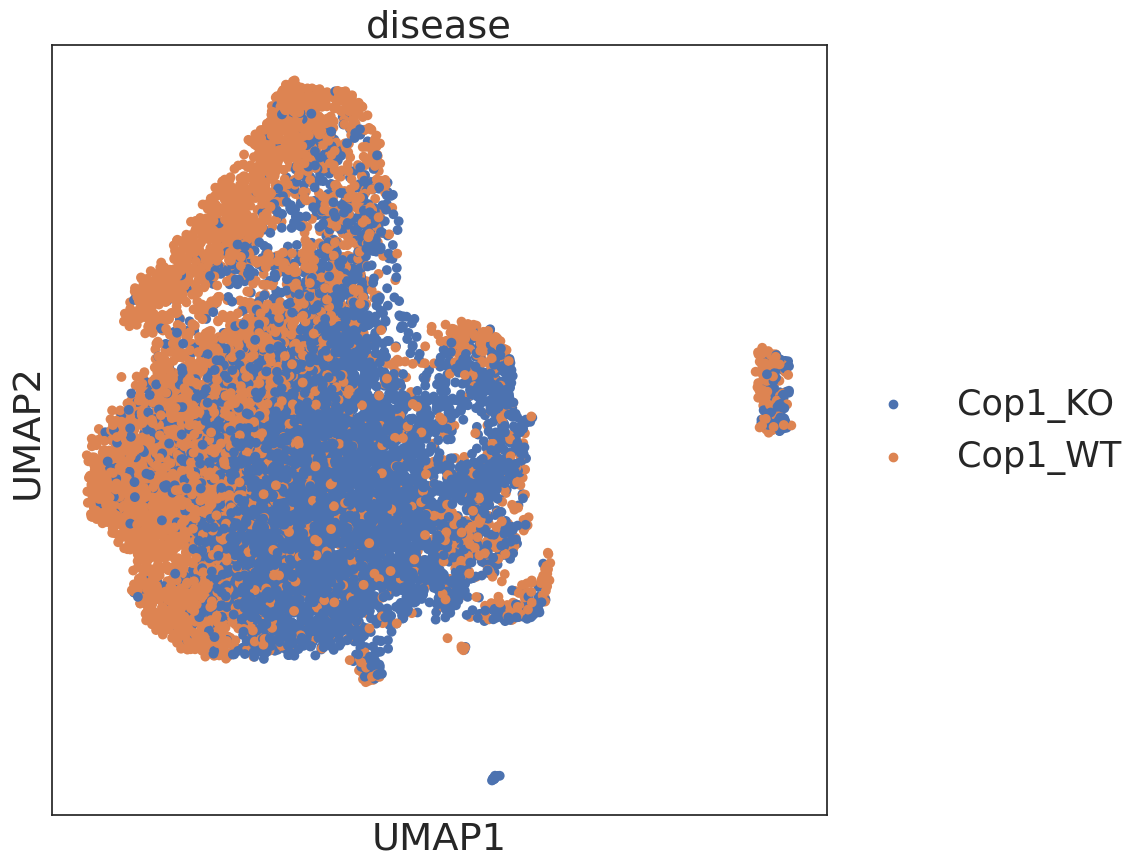

In [9]:
from geneformer import EmbExtractor
import os

# Create directory for plots if it doesn't exist
os.makedirs("/app/output/figures", exist_ok=True)


max_ncells = 2000

# Initialize EmbExtractor
embex = EmbExtractor(
    model_type="Pretrained",
    num_classes=0,
    emb_mode="cell",
    cell_emb_style="mean_pool",
    max_ncells=max_ncells,          # Adjust max_ncells if needed
    emb_layer=0,              # Same as in InSilicoPerturber
    emb_label=["disease"],
    labels_to_plot=["disease"],
    forward_batch_size=100,   # Adapted for DGX
    nproc=6
)

# Extract embeddings
embs = embex.extract_embs(
    model_directory="/app/models/mouse-Geneformer/",
    input_data_file="/app/data/Mouse-Genecorpus-20M/eval_dataset/in_silico_perturbation/Cop1KO_isp_mouse_tokenize_dataset_v-n1.dataset",
    output_directory="/app/output/figures/",
    output_prefix="Cop1KO_cell_embeddings"
)

# Plot UMAP
embex.plot_embs(
    embs=embs,
    plot_style="umap",
    output_directory="/app/output/figures/",
    output_prefix="Cop1KO",
    max_ncells_to_plot=max_ncells
)


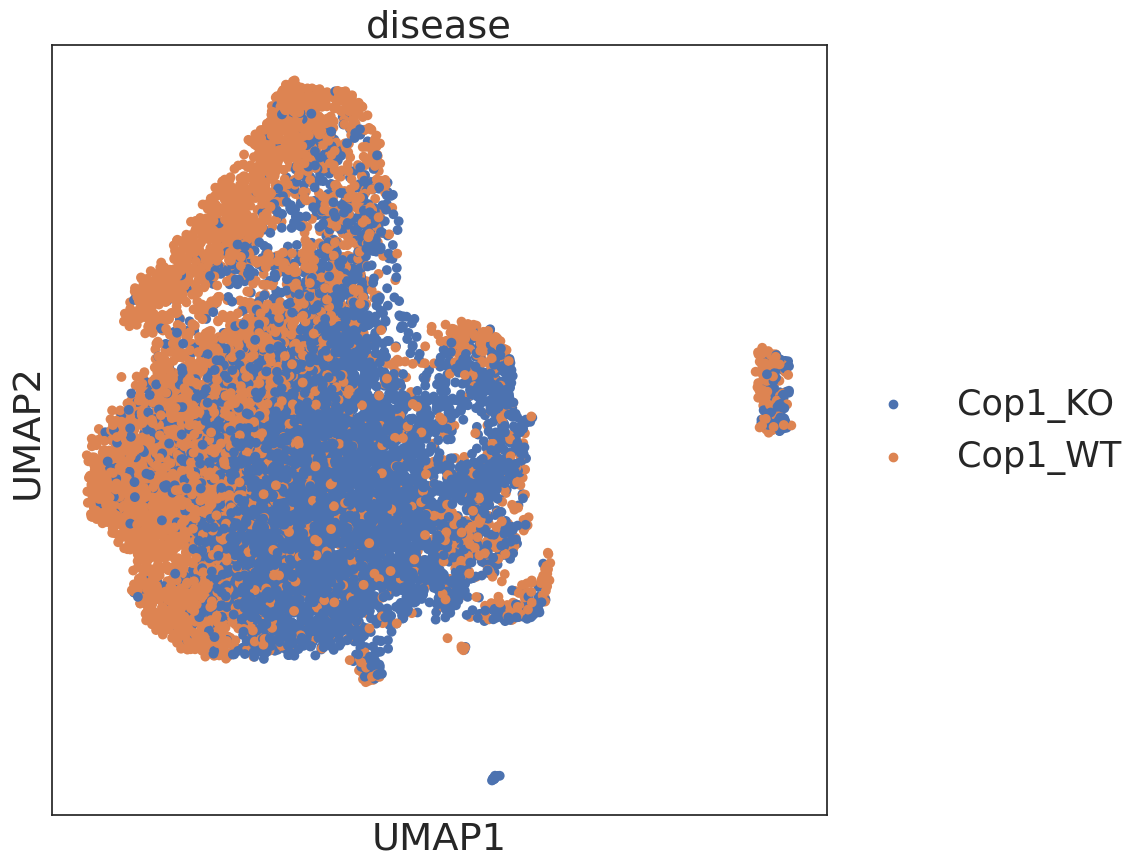